# Prediction Example

Loads both trained models and runs 4 predictions for a sample patient:
- **No PGS** (lab values only)
- **Low genetic risk** (PGS bin = 0)
- **Medium genetic risk** (PGS bin = 1)
- **High genetic risk** (PGS bin = 2)

Sample patient: sFLC ratio 1.5, M-spike 0.5 g/dL, creatinine 1.0 mg/dL, age 65.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import sys
sys.path.insert(0, '..')

from core.artifacts import CoxBootstrapBundle, PatientFeatures

In [2]:
model_nopgs  = CoxBootstrapBundle.load('models/mm_nopgs.pkl')
model_pgsbin = CoxBootstrapBundle.load('models/mm_pgs_bin.pkl')

print('Models loaded.')

Models loaded.


In [3]:
BASE = dict(age=65, m_spike=0.5, sflc_ratio=1.5, creatinine=1.0)

scenarios = [
    ('No PGS',              model_nopgs,  PatientFeatures(**BASE, pgs_bin=None), '#6b7280'),
    ('Low genetic risk',    model_pgsbin, PatientFeatures(**BASE, pgs_bin=0),    '#16a34a'),
    ('Medium genetic risk', model_pgsbin, PatientFeatures(**BASE, pgs_bin=1),    '#d97706'),
    ('High genetic risk',   model_pgsbin, PatientFeatures(**BASE, pgs_bin=2),    '#dc2626'),
]

predictions = [
    (label, color, model.predict_cumulative_incidence(patient).dropna())
    for label, model, patient, color in scenarios
]

print('Predictions done.')

Predictions done.


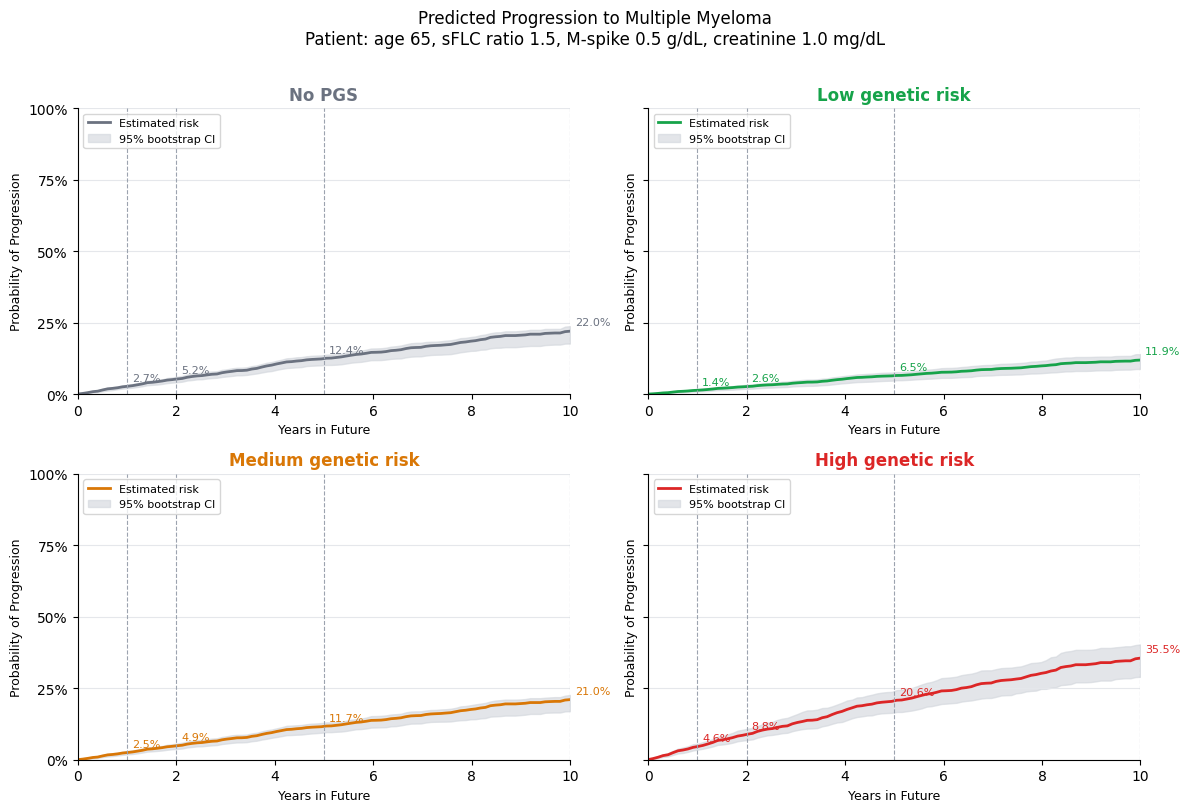

In [4]:
MILESTONES = [1, 2, 5, 10]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
axes = axes.flatten()

for ax, (label, color, df) in zip(axes, predictions):
    t = df.index.values

    # Confidence band
    ax.fill_between(t, df['ci_lower'], df['ci_upper'],
                    color='#d1d5db', alpha=0.6, label='95% bootstrap CI')

    # Risk curve
    ax.plot(t, df['risk'], color=color, linewidth=2, label='Estimated risk')

    # Milestone lines
    for yr in MILESTONES:
        if yr <= t[-1]:
            risk_at = np.interp(yr, t, df['risk'])
            ax.axvline(yr, color='#9ca3af', linewidth=0.8, linestyle='--')
            ax.text(yr + 0.1, risk_at + 0.02, f'{risk_at*100:.1f}%',
                    fontsize=8, color=color)

    ax.set_title(label, fontsize=12, fontweight='bold', color=color)
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 1)
    ax.set_xlabel('Years in Future', fontsize=9)
    ax.set_ylabel('Probability of Progression', fontsize=9)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0%', '25%', '50%', '75%', '100%'])
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', color='#e5e7eb', linewidth=0.8)

    ci_patch = mpatches.Patch(color='#d1d5db', alpha=0.6, label='95% bootstrap CI')
    risk_line = plt.Line2D([0], [0], color=color, linewidth=2, label='Estimated risk')
    ax.legend(handles=[risk_line, ci_patch], fontsize=8, loc='upper left')

fig.suptitle(
    'Predicted Progression to Multiple Myeloma\n'
    'Patient: age 65, sFLC ratio 1.5, M-spike 0.5 g/dL, creatinine 1.0 mg/dL',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig('img/prediction_example.svg', bbox_inches='tight')
plt.show()